# Big O: $O(1)$ — constant time

Big O answers: **if the input grows, how does the work grow?**

| name | written | shape |
|------|---------|--------|
| constant | $O(1)$ | a horizontal line |
| logarithmic | $O(\log n)$ | creeps up when $n$ doubles |
| linear | $O(n)$ | a straight slope |
| quadratic | $O(n^2)$ | a parabola |

$O(1)$ means the number of elementary steps **does not depend on $n$**.
Reading `items[0]` in a Python list is one address calculation. The list
can have 10 entries or $10^7$; that load still costs one step.

This notebook does not import `constant.py` or the logarithm sibling.

## Why this sits next to the quantum snippets

Deutsch–Jozsa asks a *global* question (constant vs balanced) with
**one** oracle call, for any $n$. That is $O(1)$ *queries*. Classically
you may need $2^{n-1}+1$ evaluations — exponential. The gallery starts
here so that "one shot" has a classical picture to stand on.

In [1]:
import math
import matplotlib.pyplot as plt

NS = [1, *range(100, 2001, 100)]  # 1, 100, 200, … 2000
print("n from", NS[0], "to", NS[-1])

n from 1 to 2000


## Two $O(1)$ primitives

**List index.** A CPython `list` is a contiguous array of pointers.
`items[i]` is pointer-arithmetic plus one dereference. That is $O(1)$.
(`items.append` is *amortized* $O(1)$; scanning the whole list is $O(n)$.)

**Dict lookup.** A `dict` is a hash table. Average `table[key]` is $O(1)$.
A pathological hash pile-up can degrade to $O(n)$; we ignore that here.

In [2]:
def list_get(items: list[int], index: int) -> int:
    return items[index]


def dict_get(table: dict[int, str], key: int) -> str:
    return table[key]


items = list(range(10_000))
table = {i: f"v{i}" for i in items}
print("items[0]   ", list_get(items, 0))
print("items[9999]", list_get(items, 9_999))
print("table[42]  ", dict_get(table, 42))
print("each of those did one elementary access")

items[0]    0
items[9999] 9999
table[42]   v42
each of those did one elementary access


## Count the work

We do **not** use wall-clock time. Clocks mix cache, OS noise, and
interpreter overhead. Big O is about **how many times the inner step
runs**. For a single index, that count is $1$ for every $n$.

In [3]:
def o1_steps(_n: int) -> int:
    return 1


def olog_steps(n: int) -> int:
    return 1 if n <= 1 else math.ceil(math.log2(n))


print(f"{'n':>8}  {'O(1)':>8}  {'O(log n)':>10}")
ones, logs = [], []
for n in NS:
    a, b = o1_steps(n), olog_steps(n)
    ones.append(a)
    logs.append(b)
    print(f"{n:8d}  {a:8d}  {b:10d}")

       n      O(1)    O(log n)
       1         1           1
     100         1           7
     200         1           8
     300         1           9
     400         1           9
     500         1           9
     600         1          10
     700         1          10
     800         1          10
     900         1          10
    1000         1          10
    1100         1          11
    1200         1          11
    1300         1          11
    1400         1          11
    1500         1          11
    1600         1          11
    1700         1          11
    1800         1          11
    1900         1          11
    2000         1          11


## Overlay $O(1)$ and $O(\log n)$

$n$ is an ordinary count: $1, 100, 200, \ldots, 2000$. No log tricks on
the axes. Blue stays at $1$. Orange is $\lceil\log_2 n\rceil$: it jumps
early (the first hundreds of items buy most of the comparisons) and then
**bends flat** — doubling the list later barely adds work.

At $n=2000$, constant time is still $1$ step; binary search is about
$11$ steps. When the gallery adds $O(n)$ and $O(n^2)$, those will shoot
off the top of this picture.

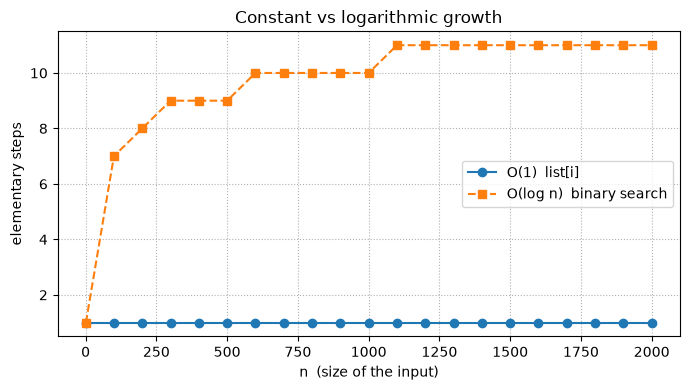

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(NS, ones, "o-", label="O(1)  list[i]")
ax.plot(NS, logs, "s--", label="O(log n)  binary search")
ax.set_xlabel("n  (size of the input)")
ax.set_ylabel("elementary steps")
ax.set_title("Constant vs logarithmic growth")
ax.legend()
ax.grid(True, which="both", linestyle=":")
fig.tight_layout()
plt.show()

## Takeaways

- $O(1)$ is a **flat line**. If your algorithm is truly constant, the
  plot must not drift when $n$ grows.
- Hash maps and arrays are the usual $O(1)$ tools. Linear scan of the
  same data is $O(n)$ — a different class.
- Deutsch–Jozsa: $O(1)$ oracle queries vs $O(2^n)$ worst-case classical
  queries. Same *word* "$O(1)$", different *resource* (queries, not RAM
  accesses).
- Next tile: `logarithm.ipynb` — measure binary-search comparisons and
  put them on the same axes.